# Enfriamiento térmico de la corteza de una estrella de neutrones

## Astrofísica Computacional

Se estudia la ecuación de difusión del calor:

$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial z^2}
-
\epsilon_\nu T^5
$$

donde:

- \(T(z,t)\): temperatura
- \($\alpha$\): difusividad térmica
- \($\epsilon_\nu$\): pérdidas por neutrinos

Se implementan tres métodos numéricos:

1. Método explícito
2. Método implícito
3. Método Crank-Nicolson

y se comparan sus propiedades de estabilidad y precisión.

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

In [53]:
# ============================================================
# PARAMETROS FISICOS
# ============================================================

L = 1e3                  # espesor de la corteza [m]
alpha = 1e-2             # difusividad termica [m^2/s]
eps_nu = 1e-53           # enfriamiento por neutrinos
T_core = 1e9             # temperatura del nucleo [K]
T_surf = 1e6             # temperatura superficial [K]

t_max = 1e6              # tiempo maximo [s]

# ============================================================
# MALLA ESPACIAL
# ============================================================

N = 100

z = np.linspace(0, L, N)

dz = z[1] - z[0]

print("Paso espacial dz =", dz)

Paso espacial dz = 10.1010101010101


# Función de condición inicial

Inicialmente toda la corteza está caliente:

$$
T(z,0)=T_{core}
$$

excepto la superficie.

In [54]:
def condicion_inicial():

    T0 = np.ones(N) * T_core

    # fronteras
    T0[0] = T_surf
    T0[-1] = T_core

    return T0

# Método Explícito

El esquema explícito para la ecuación de difusión es:

$$
T_i^{n+1}
=
T_i^n
+
\lambda
(T_{i+1}^n -2T_i^n + T_{i-1}^n)
-
\Delta t \epsilon_\nu (T_i^n)^5
$$

con:

$$
\lambda = \frac{\alpha \Delta t}{\Delta z^2}
$$

Este método es condicionalmente estable:

$$
\lambda \leq \frac12
$$

In [55]:
def metodo_explicito(dt):

    lam = alpha * dt / dz**2

    print(f"lambda = {lam}")

    if lam > 0.5:
        print("ADVERTENCIA: el metodo explicito es inestable")

    pasos = int(t_max / dt)

    T = condicion_inicial()

    tiempos_guardar = [1e3,1e4,1e5,1e6]
    pasos_guardar = {int(tg / dt) for tg in tiempos_guardar if tg >= dt}

    historial = {}

    flujo = []
    tiempo = []

    t = 0

    for n in range(pasos):

        T_new = T.copy() # para almacenar la nueva temperatura

        for i in range(1,N-1):

            difusion = lam * (T[i+1] - 2*T[i] + T[i-1])

            neutrinos = dt * eps_nu * T[i]**5

            T_new[i] = T[i] + difusion - neutrinos

        # fronteras
        T_new[0] = T_surf
        T_new[-1] = T_core

        T = T_new

        t += dt

        # flujo superficial
        F = -alpha * (T[1]-T[0])/dz

        flujo.append(abs(F))
        tiempo.append(t)

        if n + 1 in pasos_guardar:
            historial[t] = T.copy()

    return historial, np.array(tiempo), np.array(flujo)

# Método Implícito

El método implícito usa:

$$
-\lambda T_{i-1}^{n+1}
+
(1+2\lambda)T_i^{n+1}
-
\lambda T_{i+1}^{n+1}
=
T_i^n
-
\Delta t \epsilon_\nu (T_i^n)^5
$$

Este método es incondicionalmente estable.

In [56]:
def metodo_implicito(dt):

    lam = alpha * dt / dz**2

    pasos = int(t_max/dt)

    T = condicion_inicial()

    tiempos_guardar = [1e3,1e4,1e5,1e6]
    pasos_guardar = {int(tg / dt) for tg in tiempos_guardar if tg >= dt}

    historial = {}

    flujo = []
    tiempo = []

    nint = N-2

    # diagonales
    lower = -lam * np.ones(nint-1)
    main = (1 + 2*lam) * np.ones(nint)
    upper = -lam * np.ones(nint-1)

    # matriz bandada
    ab = np.zeros((3,nint))

    ab[0,1:] = upper
    ab[1,:] = main
    ab[2,:-1] = lower

    t = 0

    for n in range(pasos):

        rhs = T[1:-1] - dt*eps_nu*T[1:-1]**5

        rhs[0] += lam*T_surf
        rhs[-1] += lam*T_core

        T_int = solve_banded((1,1),ab,rhs)

        T[1:-1] = T_int

        T[0] = T_surf
        T[-1] = T_core

        t += dt

        F = -alpha*(T[1]-T[0])/dz

        flujo.append(abs(F))
        tiempo.append(t)

        if n + 1 in pasos_guardar:
            historial[t] = T.copy()

    return historial, np.array(tiempo), np.array(flujo)

# Método Crank-Nicolson

Crank-Nicolson promedia los niveles temporal \(n\) y \(n+1\):

$$
-\frac{\lambda}{2}T_{i-1}^{n+1}
+
(1+\lambda)T_i^{n+1}
-
\frac{\lambda}{2}T_{i+1}^{n+1}
=
\frac{\lambda}{2}T_{i-1}^{n}
+
(1-\lambda)T_i^n
+
\frac{\lambda}{2}T_{i+1}^{n}
$$

Tiene precisión:

$$
O(\Delta z^2)+O(\Delta t^2)
$$

y es incondicionalmente estable.

In [57]:
def metodo_crank_nicolson(dt):

    lam = alpha * dt / dz**2

    pasos = int(t_max/dt)

    T = condicion_inicial()

    tiempos_guardar = [1e3,1e4,1e5,1e6]
    pasos_guardar = {int(tg / dt) for tg in tiempos_guardar if tg >= dt}

    historial = {}

    flujo = []
    tiempo = []

    nint = N-2

    lower = -(lam/2)*np.ones(nint-1)
    main = (1+lam)*np.ones(nint)
    upper = -(lam/2)*np.ones(nint-1)

    ab = np.zeros((3,nint))

    ab[0,1:] = upper
    ab[1,:] = main
    ab[2,:-1] = lower

    t = 0

    for n in range(pasos):

        rhs = np.zeros(nint)

        for i in range(1,N-1):

            j = i-1

            rhs[j] = (
                (lam/2)*T[i-1]
                +
                (1-lam)*T[i]
                +
                (lam/2)*T[i+1]
                -
                dt*eps_nu*T[i]**5
            )

        rhs[0] += (lam/2)*T_surf
        rhs[-1] += (lam/2)*T_core

        T_int = solve_banded((1,1),ab,rhs)

        T[1:-1] = T_int

        T[0] = T_surf
        T[-1] = T_core

        t += dt

        F = -alpha*(T[1]-T[0])/dz

        flujo.append(abs(F))
        tiempo.append(t)

        if n + 1 in pasos_guardar:
            historial[t] = T.copy()

    return historial, np.array(tiempo), np.array(flujo)

# RUNNING CODE

In [78]:
# Simulación con \(\Delta t = 10^3\) s
dt1 = 1e3

hist_exp_1, t_exp_1, F_exp_1 = metodo_explicito(dt1)

hist_imp_1, t_imp_1, F_imp_1 = metodo_implicito(dt1)

hist_cn_1, t_cn_1, F_cn_1 = metodo_crank_nicolson(dt1)

lambda = 0.09801000000000001


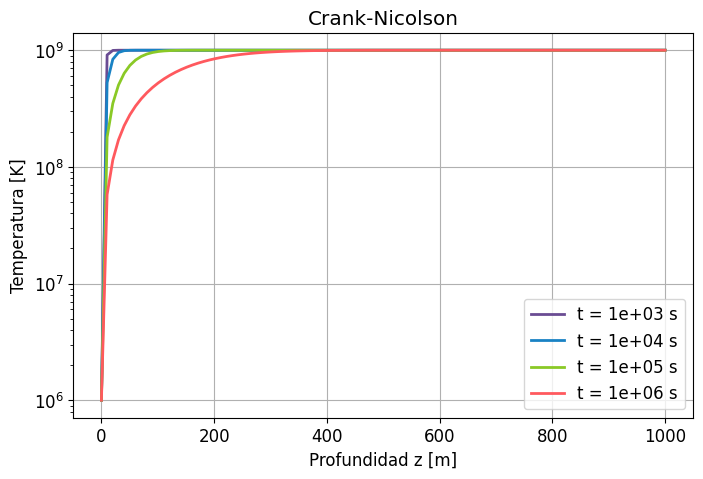

In [59]:
plt.figure()

colores_tiempo = ["#6A4C93", "#1982C4", "#8AC926", "#FF595E"]

for color, (t,val) in zip(colores_tiempo, hist_cn_1.items()):

    plt.plot(z,val,color=color,linewidth=2,label=f"t = {t:.0e} s")

plt.xlabel("Profundidad z [m]")
plt.ylabel("Temperatura [K]")

plt.yscale("log")

plt.title("Crank-Nicolson")

plt.legend()

plt.grid()

plt.show()

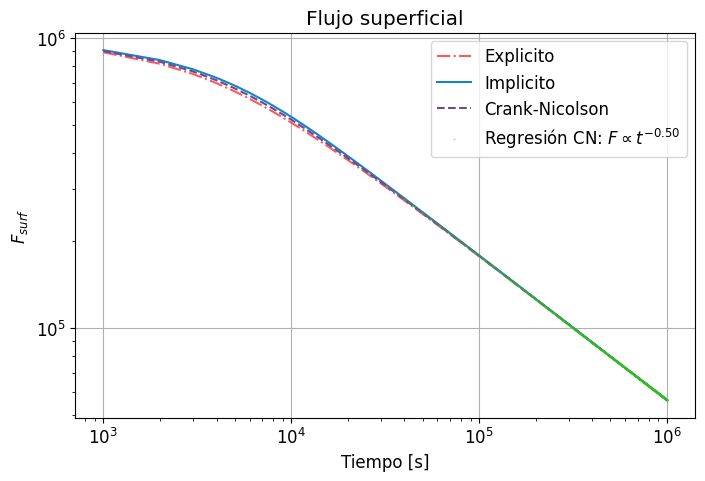

In [76]:
# Evolución temporal del flujo superficial
mask_cn = t_cn_1 > 10**4.5

log_t_cn = np.log10(t_cn_1[mask_cn])
log_F_cn = np.log10(F_cn_1[mask_cn])

pendiente_cn, intercepto_cn = np.polyfit(log_t_cn, log_F_cn, 1)
exponente_cn = -pendiente_cn

F_regresion_cn = 10**intercepto_cn * t_cn_1[mask_cn]**pendiente_cn # F = A * t^m -> log(F) = log(A) + m*log(t) el log es base 10, por eso se usa 10**intercepto_cn

plt.figure()

plt.loglog(t_exp_1,F_exp_1,color="#FF595E",linewidth=1.5,label="Explicito",linestyle="-.",alpha=1)

plt.loglog(t_imp_1,F_imp_1,color="#1982C4",linewidth=1.5,label="Implicito",linestyle="-",alpha=1)

plt.loglog(t_cn_1,F_cn_1,color="#6A4C93",linewidth=1.5,label="Crank-Nicolson",linestyle="--",alpha=1)

plt.loglog(t_cn_1[mask_cn],F_regresion_cn,color="#31C024",linewidth=0,label=fr"Regresión CN: $F \propto t^{{-{exponente_cn:.2f}}}$",marker="x",markersize=1,alpha=0.3)

plt.xlabel("Tiempo [s]")

plt.ylabel(r"$F_{surf}$")

plt.title("Flujo superficial")

plt.grid()

plt.legend()

plt.show()

In [77]:
# Simulación con \(\Delta t = 10^4\) s
dt2 = 1e4

hist_exp_2, t_exp_2, F_exp_2 = metodo_explicito(dt2)

hist_imp_2, t_imp_2, F_imp_2 = metodo_implicito(dt2)

hist_cn_2, t_cn_2, F_cn_2 = metodo_crank_nicolson(dt2)

lambda = 0.9801000000000001
ADVERTENCIA: el metodo explicito es inestable


C:\Users\pipe-desktop\AppData\Local\Temp\ipykernel_30436\1333484257.py:32: RuntimeWarning: overflow encountered in scalar power
  neutrinos = dt * eps_nu * T[i]**5
C:\Users\pipe-desktop\AppData\Local\Temp\ipykernel_30436\1333484257.py:34: RuntimeWarning: invalid value encountered in scalar add
  T_new[i] = T[i] + difusion - neutrinos
C:\Users\pipe-desktop\AppData\Local\Temp\ipykernel_30436\1333484257.py:30: RuntimeWarning: invalid value encountered in scalar subtract
  difusion = lam * (T[i+1] - 2*T[i] + T[i-1])


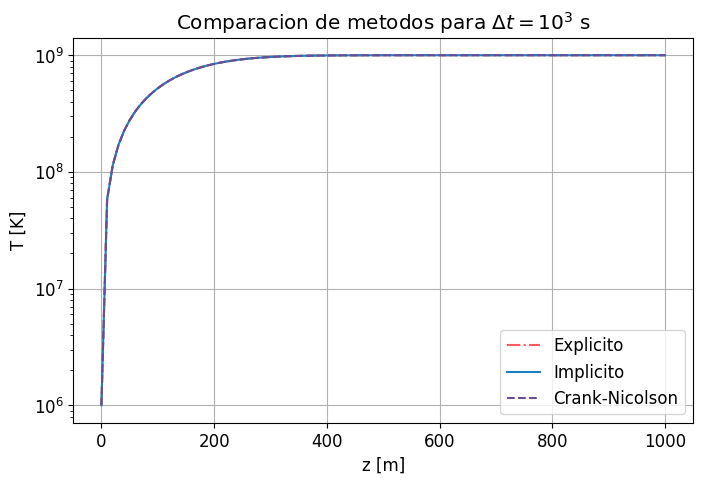

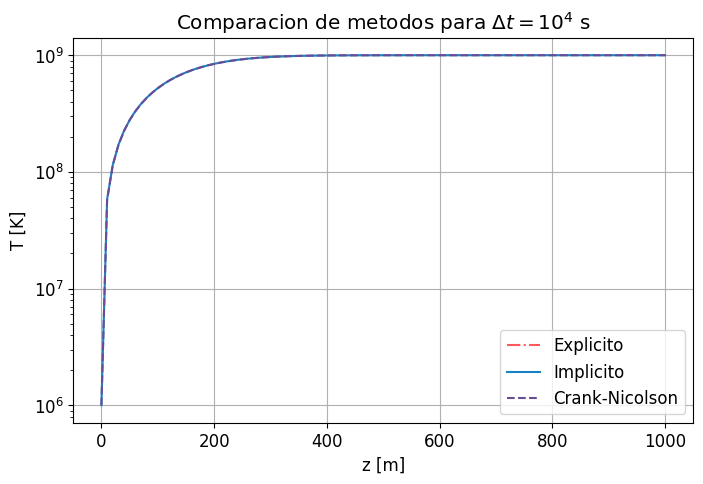

In [79]:
# Comparacion de los tres metodos para dt = 1e3 y dt = 1e4
t_final_1 = max(hist_cn_1.keys())
t_final_2 = max(hist_cn_2.keys())

plt.figure()

plt.plot(z,hist_exp_1[t_final_1],color="#FF595E",linewidth=1.5,label="Explicito",linestyle="-.")
plt.plot(z,hist_imp_1[t_final_1],color="#1982C4",linewidth=1.5,label="Implicito",linestyle="-")
plt.plot(z,hist_cn_1[t_final_1],color="#6A4C93",linewidth=1.5,label="Crank-Nicolson",linestyle="--")

plt.yscale("log")
plt.xlabel("z [m]")
plt.ylabel("T [K]")
plt.title(r"Comparacion de metodos para $\Delta t = 10^3$ s")
plt.legend()
plt.grid()
plt.show()

plt.figure()

plt.plot(z,hist_exp_2[t_final_2],color="#FF595E",linewidth=1.5,label="Explicito",linestyle="-.")
plt.plot(z,hist_imp_2[t_final_2],color="#1982C4",linewidth=1.5,label="Implicito",linestyle="-")
plt.plot(z,hist_cn_2[t_final_2],color="#6A4C93",linewidth=1.5,label="Crank-Nicolson",linestyle="--")

plt.yscale("log")
plt.xlabel("z [m]")
plt.ylabel("T [K]")
plt.title(r"Comparacion de metodos para $\Delta t = 10^4$ s")
plt.legend()
plt.grid()
plt.show()

# Discusión de estabilidad

En esta simulación la comparación entre métodos se hizo para dos pasos temporales, $\\Delta t = 10^3\,s$ y $\\Delta t = 10^4\,s$. Para interpretar los resultados se usa el parámetro de estabilidad:

$$
\lambda = \frac{\alpha \Delta t}{\Delta z^2}
$$

En el método explícito, la condición de estabilidad para la parte difusiva es:

$$
\lambda \leq \frac{1}{2}
$$

Con los parámetros usados en el código se obtiene:

$$
\lambda(\Delta t = 10^3\,s) \approx 0.098
$$

y

$$
\lambda(\Delta t = 10^4\,s) \approx 0.98
$$

Para $\Delta t = 10^3\,s$, el método explícito sí cumple la condición de estabilidad. Por eso es razonable que los tres métodos produzcan perfiles similares en la gráfica comparativa.

Para $\Delta t = 10^4\,s$, el método explícito ya no cumple la condición de estabilidad, porque $\lambda > 1/2$. Esto no significa necesariamente que en la gráfica final tenga que verse una diferencia enorme, pero sí indica que el resultado explícito no es confiable desde el punto de vista numérico. La escala logarítmica y las condiciones de frontera pueden hacer que las curvas parezcan cercanas, aun cuando el criterio de estabilidad no se cumple.

Los métodos implícito y Crank-Nicolson no están sujetos a la misma restricción de estabilidad del método explícito para la ecuación de difusión. En las gráficas calculadas, ambos métodos se mantienen suaves para los dos valores de $\Delta t$, por lo que son más convenientes cuando se usa un paso temporal grande.

A partir de estas simulaciones no se puede afirmar con precisión cuál método es “más exacto”, porque no se comparó contra una solución analítica o una solución de referencia con una malla mucho más fina. Lo que sí se puede concluir es que el método explícito es aceptable para $\Delta t = 10^3\,s$ según el criterio de estabilidad, mientras que para $\Delta t = 10^4\,s$ deja de cumplir dicho criterio. Por eso, para pasos temporales grandes, los métodos implícito y Crank-Nicolson son opciones numéricamente más seguras en este problema.


# Ley de potencia del flujo superficial

En la gráfica log-log del flujo superficial se observa que para tiempos grandes el flujo decrece aproximadamente como una ley de potencia:

$$
F_{surf}(t) \propto t^{-n}
$$

con un exponente cercano a:

$$
n \sim \frac12
$$

